## Dataset Overview

In [2]:
from scipy.io import mmread
from scipy import sparse
import pandas as pd
import numpy as np

# =========================
# Load files
# =========================

counts = mmread("data/counts.mtx")

genes = pd.read_csv(
    "data/genes.tsv",
    sep="\t",
    header=None
)[0].astype(str)

barcodes = pd.read_csv(
    "data/barcodes.tsv",
    sep="\t",
    header=None
)[0].astype(str)

print("Original matrix shape:")
print(counts.shape)

# transpose → cells x genes
counts = counts.T.tocsr()

print("\nAfter transpose:")
print(counts.shape)

Original matrix shape:
(37080, 109741)

After transpose:
(109741, 37080)


`counts.mtx`  sparse raw count matrix:

    rows = genes
    columns = cells/barcode
    svalues = raw UMI counts

In [3]:
# first 10 cells × first 10 genes
small_matrix = counts[:10, :10].toarray()

df = pd.DataFrame(
    small_matrix,
    index=barcodes[:10],
    columns=genes[:10]
)

print(df)

0                                  A1BG  A1BG-AS1  A1CF       A2M  A2M-AS1  \
0                                                                            
AKI3010018_AAACCCACAGGGATAC-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACCCATCTGATGGT-1  0.000000       0.0   0.0  0.338912      0.0   
AKI3010018_AAACCCATCTGCTTTA-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGAATCTCCAATT-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGAATCTTTCCAA-1  0.917635       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGCTAGCTTTCTT-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGCTGTCACCGAC-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGCTGTTAGAAAC-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGCTTCCACGTCT-1  0.000000       0.0   0.0  0.000000      0.0   
AKI3010018_AAACGCTTCGATACGT-1  0.000000       0.0   0.0  0.000000      0.0   

0                              A2ML1  A2ML1-AS1  A3GALT2    A4G

specific cell-এ কোন gene কত express করেছে।

In [10]:
cell_index = 0

cell_counts = counts[cell_index].toarray().flatten()

cell_df = pd.DataFrame({
    "gene": genes,
    "count": cell_counts
})

cell_df = cell_df[cell_df["count"] > 0]
cell_df = cell_df.sort_values("count", ascending=False)

print(cell_df.head(20))

          gene       count
19520   MALAT1  234.287601
30193   MT-CO2   84.260164
30192   MT-CO1   65.355341
30196   MT-CO3   37.185070
30197   MT-ND3   30.870942
30199   MT-ND4   22.301027
30195  MT-ATP6   21.972304
13349   EEF1A1   16.518551
27356   TMSB10   14.449463
30202   MT-CYB   14.195131
22404     PIGR   10.936540
16268   IGFBP7   10.797640
19376      LTF    9.922737
24343     RPS9    8.743484
20635  N4BP2L2    7.986770
30190   MT-ND1    7.912315
16692    ITM2B    7.850973
24281    RPLP1    7.440540
28669    WFDC2    7.168145
12355     CTSD    6.918192


In [5]:
gene_name = "HAVCR1"

gene_idx = np.where(genes == gene_name)[0][0]

gene_counts = counts[:, gene_idx].toarray().flatten()

gene_df = pd.DataFrame({
    "cell": barcodes,
    "count": gene_counts
})

gene_df = gene_df[gene_df["count"] > 0]

print(gene_df.head(20))

                              cell     count
55   AKI3010018_AACAGGGTCGTTGTAG-1  0.923033
117  AKI3010018_AAGCATCGTCTCACGG-1  0.976134
162  AKI3010018_AAGTCGTTCTTTCAGT-1  0.987675
182  AKI3010018_AATAGAGTCGATGCTA-1  0.970203
198  AKI3010018_AATGAAGGTTGACTAC-1  0.966150
266  AKI3010018_ACCAAACCAAGTCCAT-1  0.907490
299  AKI3010018_ACCCTTGGTCAGCTTA-1  0.926733
308  AKI3010018_ACCTGAAAGTATGCAA-1  0.986267
322  AKI3010018_ACGATCAAGGTTATAG-1  0.977925
326  AKI3010018_ACGATGTCAGCATTGT-1  1.825895
327  AKI3010018_ACGATGTCAGTGTATC-1  0.965754
329  AKI3010018_ACGCACGAGAATCGAT-1  0.991198
338  AKI3010018_ACGGGTCAGGGTACAC-1  1.964989
349  AKI3010018_ACGTACAAGTCTCGTA-1  0.779889
372  AKI3010018_ACTATTCCACCGTGCA-1  0.988286
456  AKI3010018_AGACACTTCGAACCTA-1  0.991952
526  AKI3010018_AGCGCTGTCGATTCCC-1  0.982857
529  AKI3010018_AGCGTATAGTAGCCAG-1  0.960133
546  AKI3010018_AGCTTCCTCGACCATA-1  0.987876
548  AKI3010018_AGGAATAAGAGTCAGC-1  0.949211


Sparse structure

In [6]:
print(type(counts))

print("\nNon-zero values:")
print(counts.nnz)

print("\nTotal values:")
print(counts.shape[0] * counts.shape[1])

sparsity = 100 * (
    1 - counts.nnz / (counts.shape[0] * counts.shape[1])
)

print(f"\nSparsity: {sparsity:.2f}%")

<class 'scipy.sparse._csr.csr_matrix'>

Non-zero values:
174049344

Total values:
4069196280

Sparsity: 95.72%


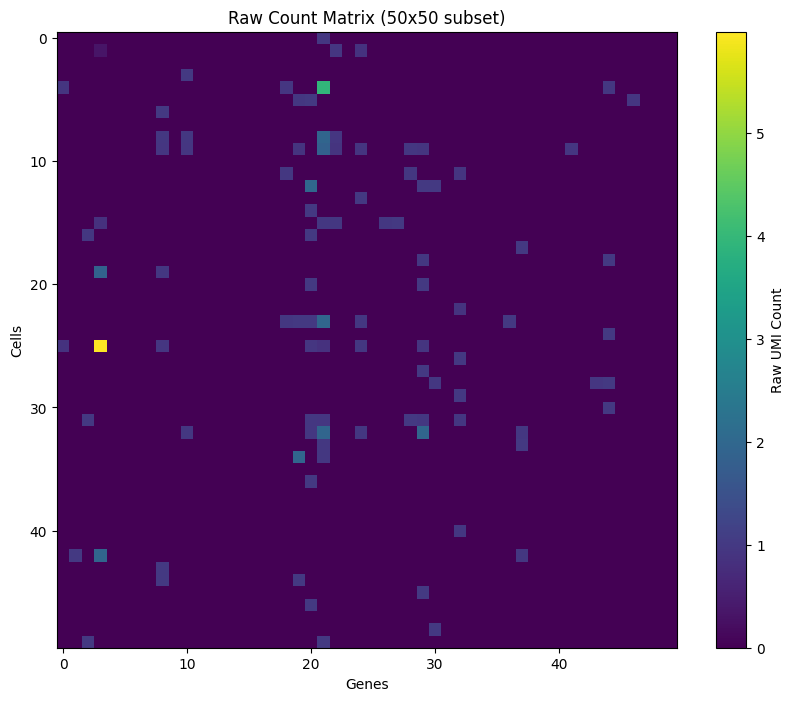

In [7]:
import matplotlib.pyplot as plt

small = counts[:50, :50].toarray()

plt.figure(figsize=(10, 8))

plt.imshow(small, aspect="auto")

plt.colorbar(label="Raw UMI Count")

plt.xlabel("Genes")
plt.ylabel("Cells")

plt.title("Raw Count Matrix (50x50 subset)")

plt.show()

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy import sparse

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

counts_file = DATA_DIR / "counts.mtx"
genes_file = DATA_DIR / "genes.tsv"
barcodes_file = DATA_DIR / "barcodes.tsv"
metadata_file = DATA_DIR / "GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt"


# =========================
# 1. Load files
# =========================

genes = pd.read_csv(genes_file, sep="\t", header=None)[0].astype(str)
barcodes = pd.read_csv(barcodes_file, sep="\t", header=None)[0].astype(str)

counts = mmread(counts_file)

if not sparse.issparse(counts):
    counts = sparse.coo_matrix(counts)

print("Raw counts.mtx shape:", counts.shape)
print("Genes file length:", len(genes))
print("Barcodes file length:", len(barcodes))

print("\nImportant:")
print("counts.mtx exported from R is usually genes x cells.")
print("So we transpose it to cells x genes for Scanpy/ML.")

counts = counts.tocsr().T.tocsr()

print("\nAfter transpose:")
print("Matrix shape:", counts.shape)
print("Expected:", (len(barcodes), len(genes)))


# =========================
# 2. Basic matrix information
# =========================

n_cells, n_genes = counts.shape
nonzero = counts.nnz
total_values = n_cells * n_genes
sparsity = 100 * (1 - nonzero / total_values)

print("\n===== Count Matrix Summary =====")
print("Cells:", n_cells)
print("Genes:", n_genes)
print("Non-zero expression values:", nonzero)
print("Total possible values:", total_values)
print(f"Sparsity: {sparsity:.2f}%")

print("\nFirst 10 genes:")
print(genes.head(10).to_string(index=False))

print("\nFirst 10 cell barcodes:")
print(barcodes.head(10).to_string(index=False))


# =========================
# 3. Per-cell QC values from raw counts
# =========================

counts_per_cell = np.asarray(counts.sum(axis=1)).ravel()
genes_per_cell = np.asarray((counts > 0).sum(axis=1)).ravel()

cell_qc = pd.DataFrame({
    "barcode": barcodes.values,
    "total_counts": counts_per_cell,
    "detected_genes": genes_per_cell
})

cell_qc.to_csv(RESULTS_DIR / "raw_cell_qc_summary.csv", index=False)

print("\n===== Cell QC Summary =====")
print(cell_qc[["total_counts", "detected_genes"]].describe())


# =========================
# 4. Per-gene QC values from raw counts
# =========================

counts_per_gene = np.asarray(counts.sum(axis=0)).ravel()
cells_per_gene = np.asarray((counts > 0).sum(axis=0)).ravel()

gene_qc = pd.DataFrame({
    "gene": genes.values,
    "total_counts": counts_per_gene,
    "expressed_cells": cells_per_gene
})

gene_qc = gene_qc.sort_values("expressed_cells", ascending=False)
gene_qc.to_csv(RESULTS_DIR / "raw_gene_qc_summary.csv", index=False)

print("\n===== Top expressed genes by number of cells =====")
print(gene_qc.head(20))


# =========================
# 5. Metadata overview
# =========================

meta = pd.read_csv(metadata_file, sep="\t", index_col=0, low_memory=False)

print("\n===== Metadata Summary =====")
print("Metadata shape:", meta.shape)
print("Metadata columns:")
print(list(meta.columns))

important_cols = [
    "condition.l1",
    "condition.l2",
    "condition.l3",
    "subclass.l1",
    "subclass.l2",
    "subclass.l3",
    "class",
    "state",
    "structure",
    "patient",
    "percent.mt",
    "nFeature_RNA",
    "nCount_RNA"
]

for col in important_cols:
    if col in meta.columns:
        print(f"\n{col} value counts:")
        print(meta[col].value_counts(dropna=False).head(20))


# =========================
# 6. Plots
# =========================

plt.figure(figsize=(8, 5))
plt.hist(counts_per_cell, bins=100)
plt.xlabel("Total UMI counts per cell")
plt.ylabel("Number of cells")
plt.title("Raw counts per cell")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_raw_counts_per_cell.png", dpi=300)
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(genes_per_cell, bins=100)
plt.xlabel("Detected genes per cell")
plt.ylabel("Number of cells")
plt.title("Detected genes per cell")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_detected_genes_per_cell.png", dpi=300)
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(cells_per_gene, bins=100)
plt.xlabel("Number of cells expressing gene")
plt.ylabel("Number of genes")
plt.title("Gene detection frequency")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_cells_per_gene.png", dpi=300)
plt.close()

if "condition.l1" in meta.columns:
    plt.figure(figsize=(8, 5))
    meta["condition.l1"].value_counts().plot(kind="bar")
    plt.xlabel("Condition")
    plt.ylabel("Number of cells")
    plt.title("Cells per condition.l1")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "04_cells_per_condition_l1.png", dpi=300)
    plt.close()

if "subclass.l1" in meta.columns:
    plt.figure(figsize=(10, 5))
    meta["subclass.l1"].value_counts().head(20).plot(kind="bar")
    plt.xlabel("Cell type subclass.l1")
    plt.ylabel("Number of cells")
    plt.title("Top cell types")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "05_top_cell_types.png", dpi=300)
    plt.close()

print("\nDone.")
print("Check results folder for:")
print("- raw_cell_qc_summary.csv")
print("- raw_gene_qc_summary.csv")
print("- 01_raw_counts_per_cell.png")
print("- 02_detected_genes_per_cell.png")
print("- 03_cells_per_gene.png")
print("- 04_cells_per_condition_l1.png")
print("- 05_top_cell_types.png")

Raw counts.mtx shape: (37080, 109741)
Genes file length: 37080
Barcodes file length: 109741

Important:
counts.mtx exported from R is usually genes x cells.
So we transpose it to cells x genes for Scanpy/ML.

After transpose:
Matrix shape: (109741, 37080)
Expected: (109741, 37080)

===== Count Matrix Summary =====
Cells: 109741
Genes: 37080
Non-zero expression values: 174049344
Total possible values: 4069196280
Sparsity: 95.72%

First 10 genes:
     A1BG
 A1BG-AS1
     A1CF
      A2M
  A2M-AS1
    A2ML1
A2ML1-AS1
  A3GALT2
   A4GALT
    A4GNT

First 10 cell barcodes:
AKI3010018_AAACCCACAGGGATAC-1
AKI3010018_AAACCCATCTGATGGT-1
AKI3010018_AAACCCATCTGCTTTA-1
AKI3010018_AAACGAATCTCCAATT-1
AKI3010018_AAACGAATCTTTCCAA-1
AKI3010018_AAACGCTAGCTTTCTT-1
AKI3010018_AAACGCTGTCACCGAC-1
AKI3010018_AAACGCTGTTAGAAAC-1
AKI3010018_AAACGCTTCCACGTCT-1
AKI3010018_AAACGCTTCGATACGT-1

===== Cell QC Summary =====
        total_counts  detected_genes
count  109741.000000   109741.000000
mean     4617.207004   